In [15]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from utils import CausalNavigator, load_cdc_data, preprocess_for_causal

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
filename = 'diabetes_binary_health_indicators_BRFSS2015.csv'
DATA_PATH = os.path.join('data', 'unprocessed', filename)
try:
    print(f"Attempting to load: {DATA_PATH}")
    df_raw = load_cdc_data(DATA_PATH)
    print(f"Data Loaded Successfully. Rows: {df_raw.shape[0]}")
except Exception as e:
    print(f"Error: {e}")
    print("Please ensure the full dataset is in the data/unprocessed/ folder.")

Attempting to load: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
Loading data from: data/unprocessed/diabetes_binary_health_indicators_BRFSS2015.csv
Dropped 24206 duplicate rows.
Data Loaded Successfully. Rows: 229474
Dropped 24206 duplicate rows.
Data Loaded Successfully. Rows: 229474


In [ ]:
# Define Causal Targets
treatment_col = 'PhysActivity'
outcome_col = 'Diabetes_binary'
# Define Covariates (Confounders)
# We use a rich set of features to satisfy the "Unconfoundedness" assumption.
# We include 'BMI' to see the direct effect, acknowledging it might be a mediator.
covariate_cols = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
    'HvyAlcoholConsump', 'AnyHealthcare', 'GenHlth', 'MentHlth', 'PhysHlth',
    'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI'
]
df_clean, X, T, Y = preprocess_for_causal(df_raw, treatment_col, outcome_col, covariate_cols)
print("--- Analysis Population ---")
print(f"Total N: {len(df_clean)}")
print(f"Treatment Rate (Active): {T.mean():.2%}")
print(f"Outcome Rate (Diabetes): {Y.mean():.2%}")

--- Analysis Population ---
Total N: 229474
Treatment Rate (Active): 73.30%
Outcome Rate (Diabetes): 15.29%


Calculating Propensity Scores and checking overlap...
Calculating Propensity Scores for Overlap Check...


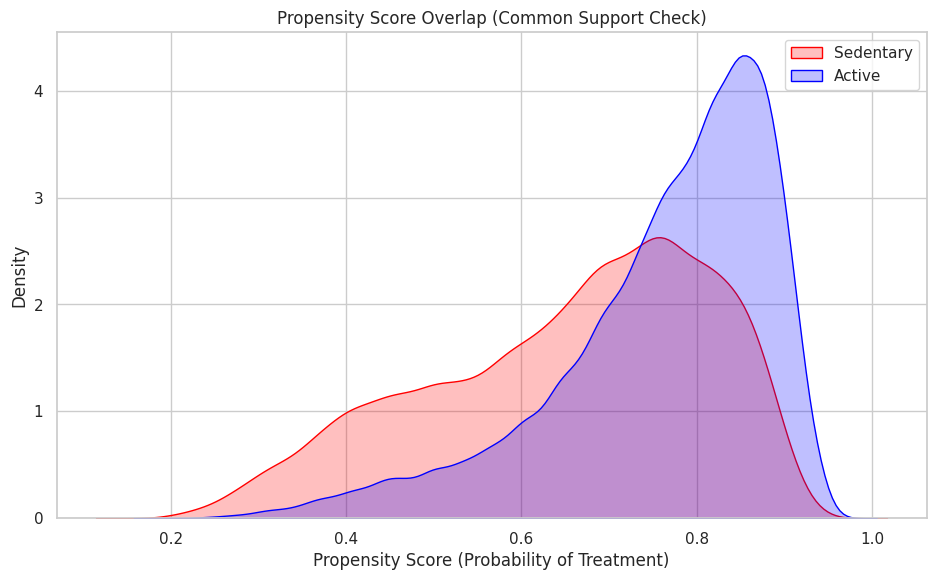


--- Diagnostic Interpretation ---
Good Overlap: The red and blue distributions share the same x-axis range.
Bad Overlap: One group is clustered at 0 and the other at 1 (Positivity Violation).



In [18]:
# Initialize our CausalNavigator with X-Learner
navigator = CausalNavigator(
    learner_type='X', 
    control_name='Sedentary', 
    treatment_name='Active'
)
# Check Common Support
print("Calculating Propensity Scores and checking overlap...")
navigator.check_overlap(X, T)

In [19]:
print("Training X-Learner on full dataset...")
# Fit the model
cate_estimates = navigator.fit_estimate(X, T, Y)
df_results = navigator.get_cate_df(df_clean)
# Calculate Overall ATE
ate = cate_estimates.mean()
print("\nTraining Complete.")
print(f"Average Treatment Effect (ATE): {ate:.4f}")
print(f"Interpretation: Physical Activity reduces diabetes risk by {abs(ate)*100:.2f}% on average.")

Training X-Learner on full dataset...
Mapping labels: 0.0 -> Sedentary, 1.0 -> Active
Training X-Learner with XGBoost base models...
Done. Estimated Average Treatment Effect (ATE): -0.0020

Training Complete.
Average Treatment Effect (ATE): -0.0020
Interpretation: Physical Activity reduces diabetes risk by 0.20% on average.
Done. Estimated Average Treatment Effect (ATE): -0.0020

Training Complete.
Average Treatment Effect (ATE): -0.0020
Interpretation: Physical Activity reduces diabetes risk by 0.20% on average.


Analyzing Heterogeneity by Age...


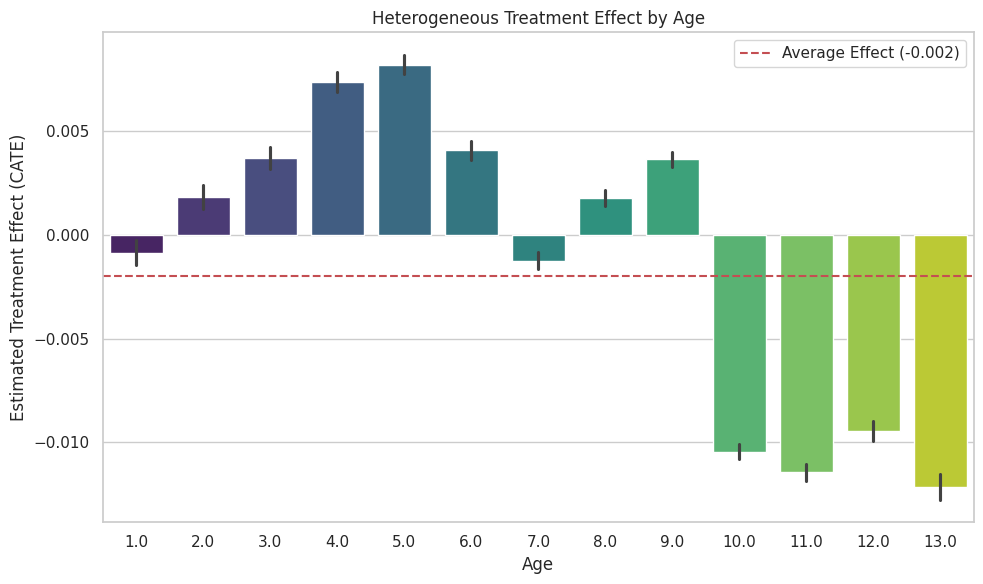

In [20]:
# Question: Does the benefit of exercise increase as we age?
# Age 1 = 18-24, Age 13 = 80+
print("Analyzing Heterogeneity by Age...")
navigator.plot_heterogeneity(df_results, col='Age')

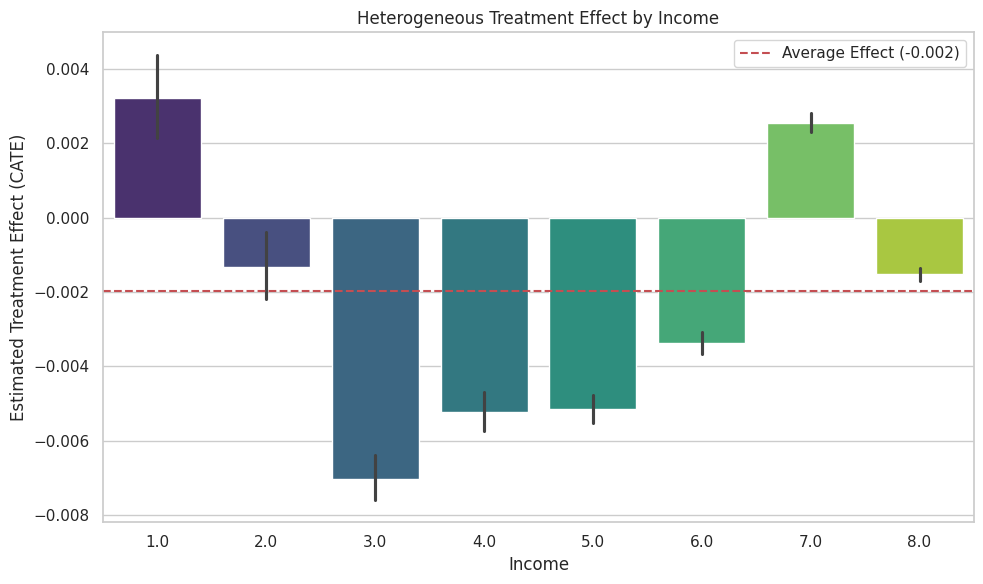

In [21]:
# Question: Is the effect consistent across Income levels?
# Income 1 = <$10k, Income 8 = >$75k
navigator.plot_heterogeneity(df_results, col='Income')

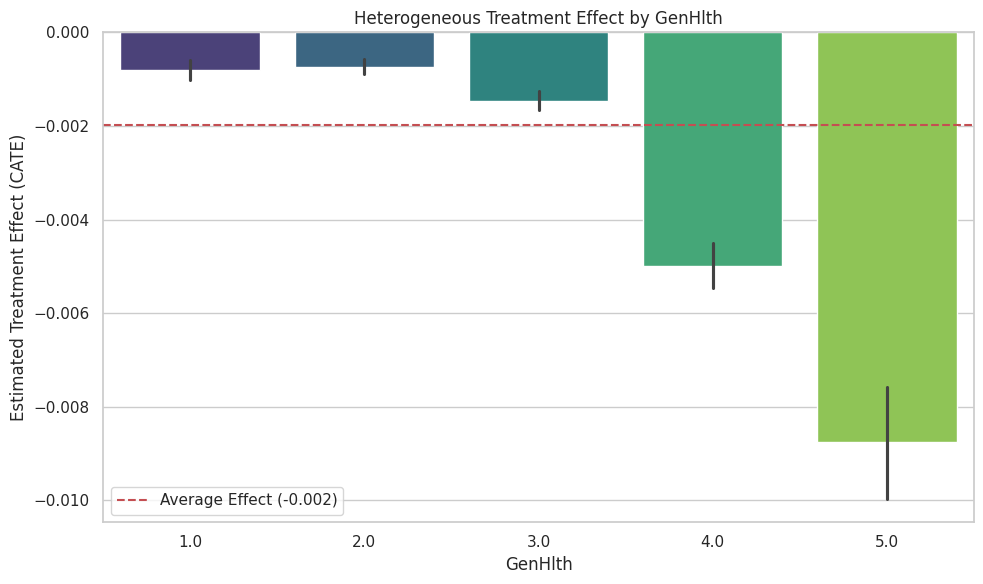

In [22]:
# Question: Who benefits more? People who already feel healthy (1-2) or those with poor health (4-5)?
# GenHlth: 1=Excellent, 5=Poor
navigator.plot_heterogeneity(df_results, col='GenHlth')